# Phase 9.A — CLIP Smoke Test

Goal: verify open_clip works end-to-end on real crops, and check whether the
`similarity_margin: 0.05` threshold is calibrated correctly.

Three questions:
1. Does `clip` load and embed images at the right shape?
2. Do real-person prompts score higher than ad prompts on real photos?
3. What's the typical margin? Is 0.05 too tight or too loose?

The mannequin crop from previous smoke runs (crop 1022) is the smoking gun
— if CLIP can't distinguish it from a real photo, our prompts are wrong.

In [1]:
from __future__ import annotations 

from pathlib import Path 
import numpy as np 

import cv2  
import torch
from transformers import CLIPModel,CLIPProcessor
import yaml

from src.constants import IMAGES_DIR,CLIP_MODEL_ID,DEVICE
from src.utils.io import ImageLoader 
from src.logger.custom_logger import configure_logger

10:35:59 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-11\10-35-59.log


In [2]:
configure_logger(log_level="WARNING")

WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-11/10-35-59.log')

In [3]:
model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)

THRESHOLDS_PATH = Path("../config/thresholds.yaml")

with THRESHOLDS_PATH.open() as f:
    cfg = yaml.safe_load(f)

real_prompts = cfg['clip_ad_filter']['real_person_prompts']
ad_prompts = cfg['clip_ad_filter']['ad_prompts']
margin_thresholds = cfg['clip_ad_filter']['similarity_margin']

print(f"Real prompts: {real_prompts}\n")
print(f"Ad prompts: {ad_prompts}")
print(f"Margin: {margin_thresholds}")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Real prompts: ['a candid snapshot of a real person in a natural setting', 'an unposed photo of a pedestrian on a city street', 'a casual phone photograph of someone walking', 'a real human being photographed in everyday life', 'a documentary photograph of a person outdoors']

Ad prompts: ['a mannequin on display in a clothing store window', 'a plastic mannequin wearing clothes for sale', 'a fashion advertisement photographed in a studio', 'a clothing store storefront with mannequin displays', 'a magazine fashion shoot with professional lighting', 'a retail product display photograph']
Margin: 0.0


### Embed prompts


In [4]:
from torch.nn import functional as F

def encode_text(texts: list[str]) -> torch.Tensor:
    """Embed prompts once this will return L2 normalized embeddings"""
    inputs = processor(text=texts,
                       return_tensors='pt',
                       padding=True).to(DEVICE)
    
    with torch.no_grad():
        embeddings = model.get_text_features(**inputs)
    

    if not isinstance(embeddings,torch.Tensor):
        embeddings = embeddings.pooler_output

    embeddings = F.normalize(embeddings,dim=1)
    # L2 normalization

    return embeddings

real_emd = encode_text(real_prompts)
ad_emd = encode_text(ad_prompts)
print(f"Real embeddings shape: {real_emd.shape}")
print(f"Ad embeddings shape:{ad_emd.shape}")
print(f"Embeddings L2 norm: {real_emd[0].norm().item():.4f}")

Real embeddings shape: torch.Size([5, 512])
Ad embeddings shape:torch.Size([6, 512])
Embeddings L2 norm: 1.0000


### Score on a manequin image

In [5]:
from PIL import Image

loader = ImageLoader()

def score_crop(crop_img_rgb: np.ndarray) -> dict[str,float]:
    """Encode crop image and compute max similarity vs real and ad_prompts"""
    pil_img = Image.fromarray(crop_img_rgb)
    inputs = processor(images=pil_img,return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        img_emd = model.get_image_features(**inputs)

    if not isinstance(img_emd,torch.Tensor):
        img_emd = img_emd.pooler_output

    img_emd = F.normalize(img_emd,dim=1)

    real_scores = (img_emd @ real_emd.T).squeeze(0).cpu().numpy()
    ad_scores = (img_emd @ ad_emd.T).squeeze(0).cpu().numpy()

    return {"best_real_score":float(real_scores.max()),
            "best_real_prompt":real_prompts[int(real_scores.argmax())],
            "best_ad_score":float(ad_scores.max()),
            "best_ad_prompt":ad_prompts[int(ad_scores.argmax())],
            "margin":float(real_scores.max() - ad_scores.max())}

# test on manequin img 
mannequin_crop = loader.load(IMAGES_DIR / "crop (1022).png")
result = score_crop(mannequin_crop.image)
print("Mannequin crop (1022):")
for k, v in result.items():
    print(f"  {k}: {v}")


Mannequin crop (1022):
  best_real_score: 0.24571116268634796
  best_real_prompt: a casual phone photograph of someone walking
  best_ad_score: 0.25852063298225403
  best_ad_prompt: a mannequin on display in a clothing store window
  margin: -0.012809470295906067


### Score on real person

In [6]:
# Try a couple of known-real crops
real_crop_ids = ["crop (33)", "crop (1006)"]  # adjust if needed

for cid in real_crop_ids:
    path = IMAGES_DIR / f"{cid}.png"
    if not path.exists():
        print(f"  {cid}: not found")
        continue
    crop = loader.load(path)
    result = score_crop(crop.image)
    print(f"\n{cid}:")
    print(f"  best_real: {result['best_real_score']:.3f} ({result['best_real_prompt'][:40]})")
    print(f"  best_ad:   {result['best_ad_score']:.3f} ({result['best_ad_prompt'][:40]})")
    print(f"  margin:    {result['margin']:+.3f}")


crop (33):
  best_real: 0.245 (a real human being photographed in every)
  best_ad:   0.220 (a plastic mannequin wearing clothes for )
  margin:    +0.025

crop (1006):
  best_real: 0.232 (a real human being photographed in every)
  best_ad:   0.202 (a plastic mannequin wearing clothes for )
  margin:    +0.029


### Score across dataset for margin distribution 

In [7]:
from src.components.age_filter import AgeFilter
from src.components.face_filter import FaceFilter
from src.components.person_detector import PersonDetector
from src.components.pose_filter import PoseFilter
from src.components.quality_filter import QualityFilter
from src.settings.config import (AgeThresholds,
                                 FaceThresholds,
                                 PersonDetectionThresholds,
                                 PoseThresholds,
                                 QualityThresholds)

quality_filter = QualityFilter(QualityThresholds())
detector = PersonDetector(PersonDetectionThresholds())
pose = PoseFilter(PoseThresholds())
face = FaceFilter(FaceThresholds())
age = AgeFilter(AgeThresholds())

stage_4_passers = []
for path in sorted(IMAGES_DIR.glob("*.png")): 
    crop = loader.load(path)
    if not quality_filter.apply(crop).passed:
        continue
    if not detector.apply(crop).passed:
        continue
    if not pose.apply(crop).passed:
        continue
    if not face.apply(crop).passed:
        continue
    if not age.apply(crop).passed:
        continue
    stage_4_passers.append(crop)

print(f"Crops surviving Stages 0-4: {len(stage_4_passers)}")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\rsurs/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Crops surviving Stages 0-4: 163


In [8]:
records = []
for crop in stage_4_passers:
    r = score_crop(crop.image)
    r["crop_id"] = crop.crop_id
    records.append(r)

import pandas as pd

df_clip = pd.DataFrame(records)
print(df_clip[["crop_id", "best_real_score", "best_ad_score", "margin"]].head(15))
print()
print("Margin statistics:")
print(df_clip["margin"].describe().round(3))

        crop_id  best_real_score  best_ad_score    margin
0   crop (1006)         0.231609       0.202195  0.029413
1    crop (102)         0.258459       0.230892  0.027567
2   crop (1022)         0.245711       0.258521 -0.012809
3   crop (1049)         0.265409       0.248208  0.017201
4   crop (1053)         0.269280       0.234737  0.034543
5   crop (1057)         0.263300       0.221092  0.042208
6   crop (1068)         0.259092       0.249365  0.009727
7    crop (108)         0.276127       0.215240  0.060887
8   crop (1088)         0.255240       0.225375  0.029864
9   crop (1093)         0.234419       0.201999  0.032419
10  crop (1110)         0.246601       0.219957  0.026643
11  crop (1123)         0.255940       0.256352 -0.000412
12   crop (140)         0.255545       0.233526  0.022019
13   crop (182)         0.256398       0.248541  0.007857
14   crop (183)         0.259704       0.214005  0.045698

Margin statistics:
count    163.000
mean       0.020
std        0.021
m

### Histogram + threshold visualization


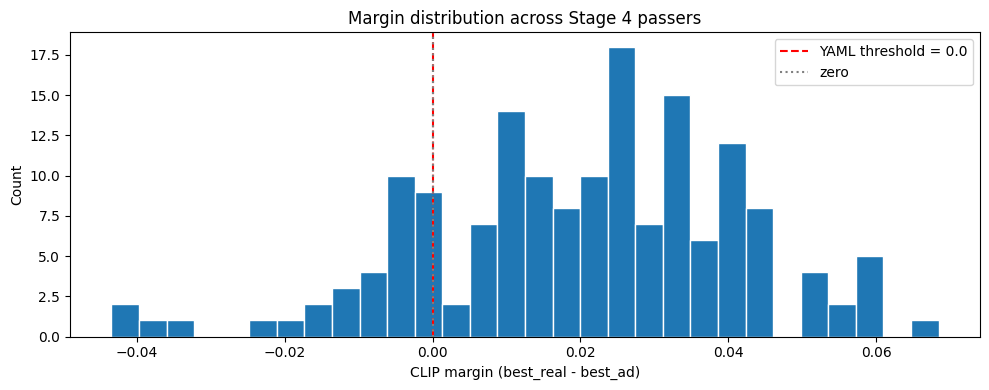


With threshold 0.0: 131 of 163 would pass
With threshold 0.00:  131 of 163 would pass
With threshold 0.10:  0 of 163 would pass


In [9]:
import matplotlib.pyplot as plt

margin = margin_thresholds
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clip["margin"], bins=30, edgecolor="white")
ax.axvline(margin, color="red", linestyle="--", label=f"YAML threshold = {margin}")
ax.axvline(0, color="gray", linestyle=":", label="zero")
ax.set_xlabel("CLIP margin (best_real - best_ad)")
ax.set_ylabel("Count")
ax.set_title("Margin distribution across Stage 4 passers")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nWith threshold {margin}: {(df_clip['margin'] >= margin).sum()} of {len(df_clip)} would pass")
print(f"With threshold 0.00:  {(df_clip['margin'] >= 0).sum()} of {len(df_clip)} would pass")
print(f"With threshold 0.10:  {(df_clip['margin'] >= 0.10).sum()} of {len(df_clip)} would pass")